In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, SplineTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Set style
sns.set_theme(style="whitegrid")

## 1. Load and Preprocess Data for Splines

In [2]:
# Load the dataset
full_dataset = pd.read_csv("dataset.csv")
full_dataset = full_dataset.dropna()

# Filter to students
dataset = full_dataset[full_dataset["Profession"] == "Student"].reset_index(drop=True)

# Drop unnecessary variables natively
dataset = dataset.drop(columns=["id", "City", "Profession", "Work Pressure", "Job Satisfaction"])

# Remove "Others"
dataset = dataset[dataset["Sleep Duration"] != "Others"].copy()
dataset = dataset[dataset["Dietary Habits"] != "Others"].copy()

# Target
y = dataset['Depression']

# Basic Features (No manual interactions here so we let splines handle non-linearities natively)
X = dataset.drop(columns=['Depression', 'Have you ever had suicidal thoughts ?'])

# Define Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Which features get Splines vs OHE vs Passthrough?
continuous_features = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Study Satisfaction']
categorical_features = ['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Family History of Mental Illness']

print(f"Training features shape: {X_train.shape}")

Training features shape: (22269, 11)


## 2. Apply Spline Transformers & Logistic Regression (GAM style)
We apply B-Splines (degree 3, 4 knots) to continuous predictors. This essentially turns `CGPA` into 6 separate features capturing non-linear polynomial chunks.

In [3]:
# Column transformer
spline_preprocessor = ColumnTransformer(
    transformers=[
        # Spline transformation on continuous data
        ('splines', SplineTransformer(n_knots=4, degree=3, include_bias=False), continuous_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Pipeline
model_spline = Pipeline(steps=[
    ('preprocessor', spline_preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

# Train the Spline-Enhanced Logistic Regression Model
model_spline.fit(X_train, y_train)

# Evaluate
y_pred = model_spline.predict(X_test)
y_proba = model_spline.predict_proba(X_test)[:, 1]

print("--- Spline Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

--- Spline Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      2310
           1       0.83      0.81      0.82      3258

    accuracy                           0.79      5568
   macro avg       0.78      0.79      0.79      5568
weighted avg       0.79      0.79      0.79      5568

ROC-AUC: 0.8676
Accuracy: 0.7911


## 3. Visualize the Non-Linear Spline Effects
Let's plot how CGPA and Age uniquely impact the prediction probability across their entire range if we hold all other factors constant at their mean/mode!

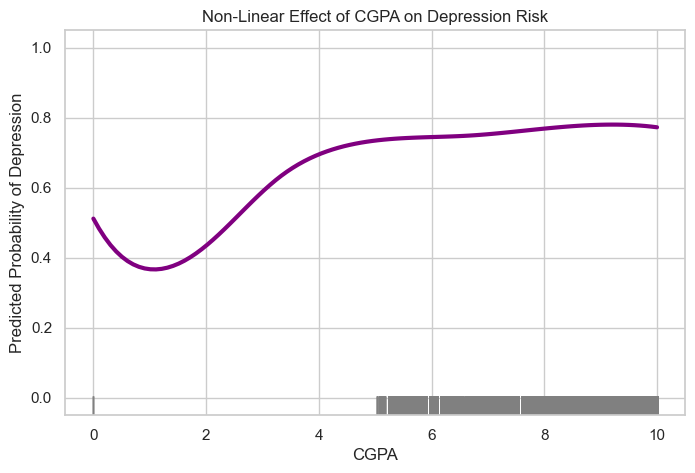

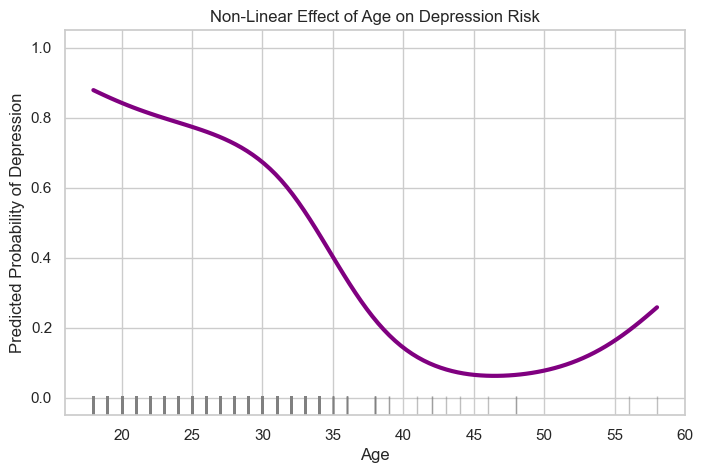

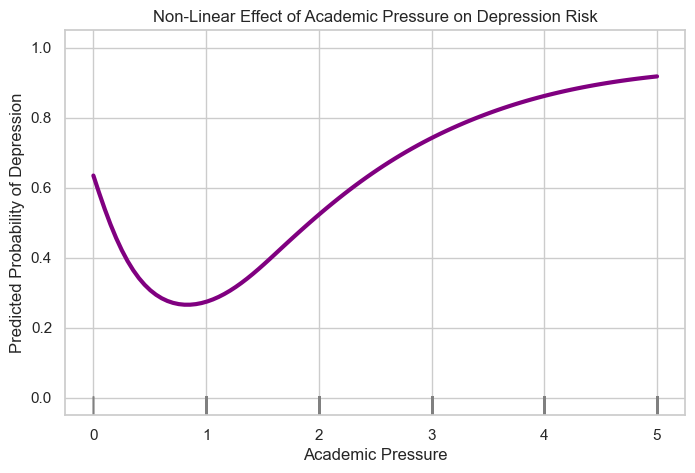

In [ ]:
def plot_spline_effect(variable_name, X_train_original, pipeline, min_val=None, max_val=None, num_points=100):
    # Find mode/mean of training data to use as the "baseline student"
    baseline_student = X_train_original.mode().iloc[0].copy()
    
    # Calculate means for continuous ones (to make them more realistic than mode)
    for col in continuous_features:
        baseline_student[col] = X_train_original[col].mean()
        
    # Generate X coordinates to evaluate
    x_min = X_train_original[variable_name].min() if min_val is None else min_val
    x_max = X_train_original[variable_name].max() if max_val is None else max_val
    x_eval = np.linspace(x_min, x_max, num_points)
    
    # Create fake dataframe of the baseline student repeated num_points times
    fake_data = pd.DataFrame([baseline_student]*num_points)
    
    # Inject the variable sequence
    fake_data[variable_name] = x_eval
    
    # Predict Probability
    y_pred_proba = pipeline.predict_proba(fake_data)[:, 1]
    
    # Plotting!
    plt.figure(figsize=(8, 5))
    plt.plot(x_eval, y_pred_proba, color='purple', linewidth=3)
    plt.title(f"Non-Linear Effect of {variable_name} on Depression Risk")
    plt.xlabel(variable_name)
    plt.ylabel("Predicted Probability of Depression")
    plt.ylim(-0.05, 1.05)
    
    # Plot rug/histogram at bottom to see where original data actually sits
    sns.rugplot(X_train_original[variable_name], height=0.05, color='gray', alpha=0.5)
    plt.show()

# Plot CGPA
plot_spline_effect("CGPA", X_train, model_spline)

# Plot Age
plot_spline_effect("Age", X_train, model_spline)

# Plot Academic Pressure
plot_spline_effect("Academic Pressure", X_train, model_spline)


## 4. Machine Learning Evaluation (Cross-Validation)
We apply 5-Fold Stratified Cross-Validation to ensure our GAM proxy is robust and not just overfitting to a single train/test split.

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use StratifiedKFold to maintain the ratio of depressed vs non-depressed students
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-Fold Cross Validation for ROC-AUC
scores = cross_val_score(model_spline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"--- 5-Fold Cross-Validation (ROC-AUC) ---")
print(f"Individual Fold Scores: {[f'{s:.4f}' for s in scores]}")
print(f"Mean AUC Score: {scores.mean():.4f}")
print(f"Standard Deviation: +/- {scores.std():.4f}")


--- 5-Fold Cross-Validation (ROC-AUC) ---
Individual Fold Scores: ['0.8709', '0.8688', '0.8856', '0.8669', '0.8742']
Mean AUC Score: 0.8733
Standard Deviation: +/- 0.0066


## 5. Confusion Matrix
A graphical representation demonstrating exactly how many True Positives (depressed students correctly identified) VS False Positives our GAM predicts on the unseen test set.

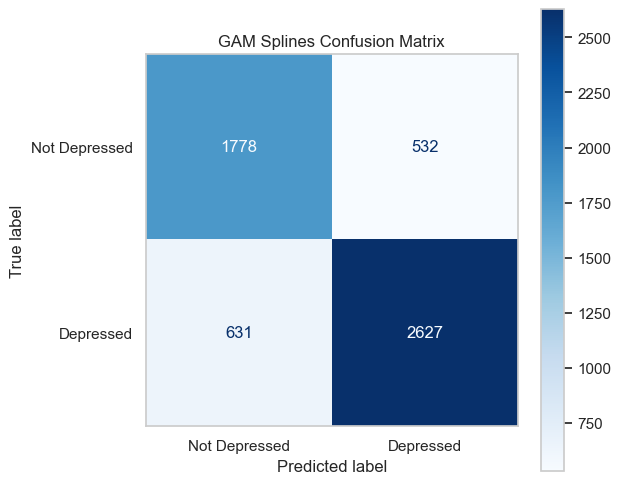

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Regenerate predictions for test set
y_pred = model_spline.predict(X_test)

# Plot the matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Depressed", "Depressed"]
)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax)
plt.title("GAM Splines Confusion Matrix")
plt.grid(False)
plt.show()
